In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

%matplotlib inline

In [4]:
def f_seir_ld(x, t, gamma=1.0/18, sigma=1/5.2, R0_1=2.0, R0_2=0.5, t_change=100, eta=1.0/20, delta=0.01):
    """
    Model with two target R0s which are switched after t_change timesteps,
    which can be interpreted as the implementation of a lockdown/other mitigation methods.
    """
    s, e, i, r, R0, c, d = x
    
    # switch target R0 after t_change
    R0_inf = R0_1 if t < t_change else R0_2
    
    dydt = [-gamma*R0*s*i,           # ds/dt
            gamma*R0 *s*i - sigma*e, # de/dt
            sigma*e - gamma*i,       # di/dt
            gamma*i,                 # dr/dt
            eta*(R0_inf - R0), # change of current R0 to target R0. Required, as the target R0 established by some policy is not reached instantaneously.
            sigma*e,           # cumulative case load
            delta*gamma*i      # number of deaths
    ]
    return dydt

## SEIR: The effect of R0 and differing starting conditions.
- Set the starting conditions **e_0, r_0, i_0, s_0** for our model (remember, that they are the normalized values, i.e. the small letter variables in the slides).
- Evaluate and plot the model for differing starting times of the lockdown and varying **R0**s (for both the lockdown-R0 and the unregulated (No-Lockdown) R0).
- Assuming no lockdown interferes and the epidemic naturally procedes, what effect does the unregulated (No-Lockdown) **R0** have on the total number of infected? 
- Expand the model with the assumption that a proportion of the population is vaccinated before the outbreak (and assume the vaccination grants 100% immunity). Hint: You do not have to change the differential equations. 
- What proportion has to be vaccinated to achieve herd immunity and avoid an outbreak? Does it depend on R0 and if so, can you empirically find a relation?

In [5]:
vaccinated = 0.

e_0 = 0 # exposed
r_0 = 0 # recovered
i_0 = 10e-7 # infected
s_0 = 1-i_0 # suseptable

N = 300*1000*1000

In [10]:
# R0 for Lockdown and No-Lockdown
R0_L = 0.5
R0_NL = 2.
t_change_list =  [20, 50, 100, 300]

# if lift: Start with lockdown, lift it after some time
# else, the other way around.
lift = False
R0_1, R0_2 = (R0_L, R0_NL) if lift else (R0_NL, R0_L)

# initial values / starting conditions
y_0 = [s_0, e_0, i_0, r_0, R0_1, 0, 0]

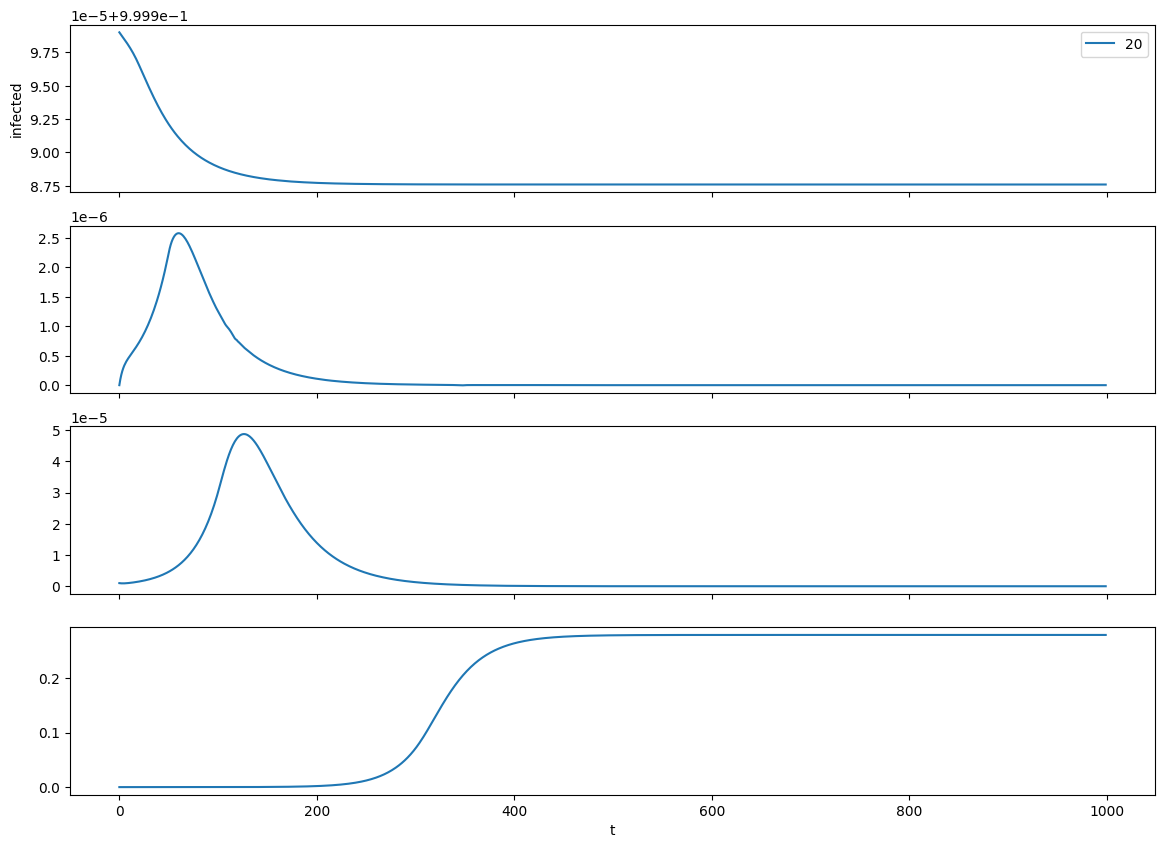

In [14]:
# time range
T = 1000
# time step size
dt = 1
tspan = np.arange(0.0, T, dt)

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for n,t_change in enumerate(t_change_list):
    f_seir_ld_t = lambda x, t : f_seir_ld(x, t, gamma=1.0/18, sigma=1/5.2, t_change=t_change, R0_1=R0_1, R0_2=R0_2)
    
    y = odeint(f_seir_ld_t, y_0, tspan)
    deaths = N * y[:, -1]
    axs[n].plot(tspan, y[:, n], label=t_change)

    
    # TODO: Plot the other values (s, e, r)

plt.xlabel("t")
axs[0].legend()
axs[0].set_ylabel("infected")
plt.show()
plt.close()

## Multiple Lockdowns
Often, stronger measures for decreasing the target R0 (lockdowns) are relaxed after some time and have to be reinstated again as soon as the number of cases increases. 
However, the reintroduction of the measures might be slower, i.e. the transition to the target R0 can be slower. 

Change the function `f_seir_two_lds` such that our model has two lockdowns at different times, where the second lockdown has a slower rate of reaching the target (Lockdown) R0. You will only need a slow modification of the previous `f_seir_ld`.

Can you recognize a well-known phenomenon in the number of infected?

In [84]:
    # TODO: Change this function
    def f_seir_two_lds(x, t, gamma=1.0/18, sigma=1/5.2, R0_1=2.0, R0_2=0.5, t_change=100, eta=1.0/20, delta=0.01):
        s, e, i, r, R0, c, d = x
        
        # switch target R0 after t_change
        R0_inf = R0_1 if t < t_change else R0_2
        
        dydt = [-gamma*R0*s*i,           # ds/dt
                gamma*R0 *s*i - sigma*e, # de/dt
                sigma*e - gamma*i,       # di/dt
                gamma*i,                 # dr/dt
                eta*(R0_inf - R0), # change of current R0 to target R0. Required, as the target R0 established by some policy is not reached instantaneously.
                sigma*e,           # cumulative case load
                delta*gamma*i      # number of deaths
        ]
        return dydt

[20, 50, 100, 300]
[40, 100, 200, 600]
[60, 150, 300, 900]
[80, 200, 400, 1200]


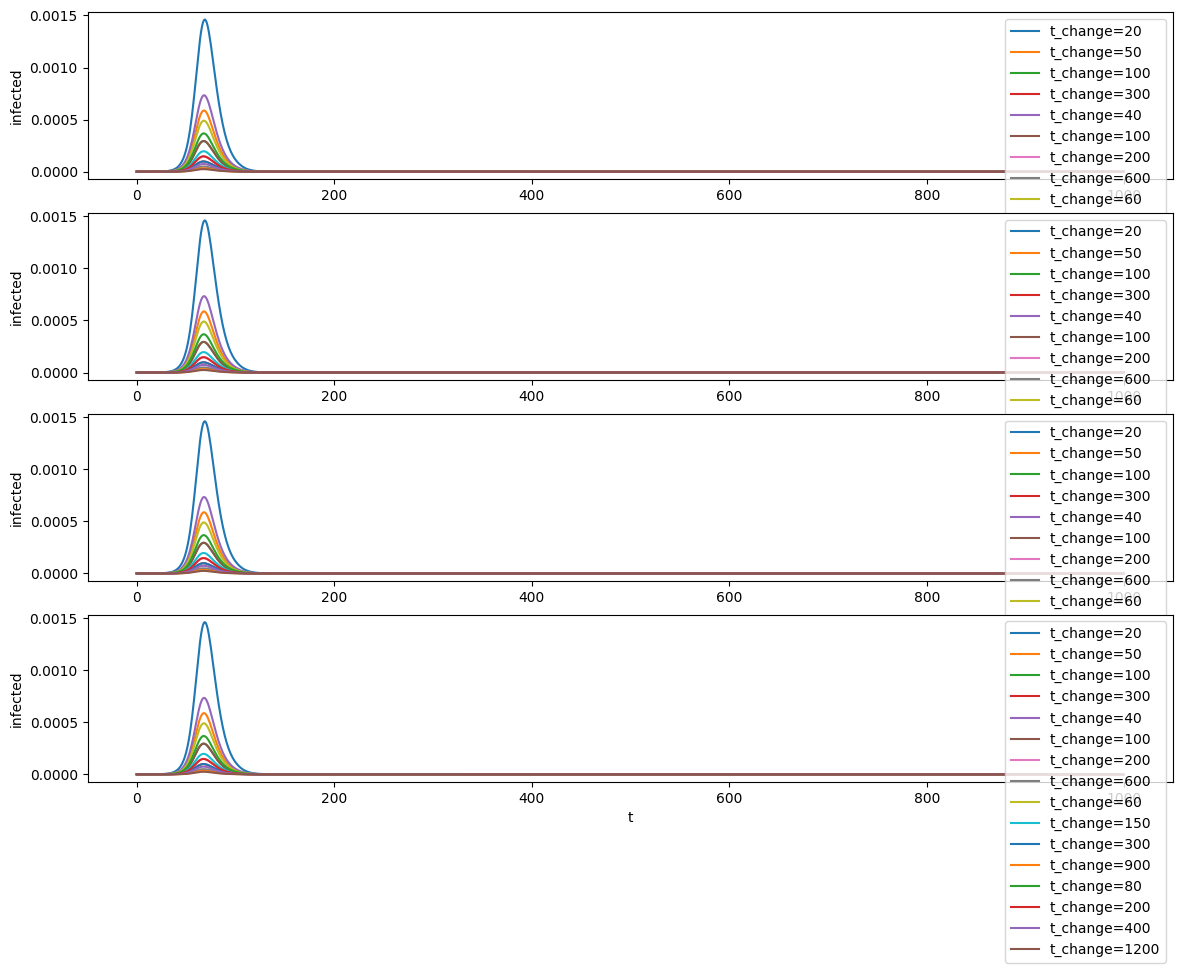

In [85]:
e_0 = 0 # exposed
r_0 = 0 # recovered
i_0 = 10e-7 # infected
s_0 = 1-i_0 # suseptable

N = 300*1000*1000

# R0 for Lockdown and No-Lockdown
R0_L = 0.5
R0_NL = 2.
t_change_list =  [20, 50, 100, 300]

# if lift: Start with lockdown, lift it after some time
# else, the other way around.
lift = False
R0_1, R0_2 = (R0_L, R0_NL) if lift else (R0_NL, R0_L)

y_0 = [s_0, e_0, i_0, r_0, R0_1, 0, 0]


T = 1000
dt = 1
tspan = np.arange(0.0, T, dt)

fig, axs = plt.subplots(4, 1, figsize=(14, 10))
iterr = 0

for i in range(4):
    # scale t_change_list by i
    repeated_list = [el * (i+1) for el in t_change_list]  # use i+1 to avoid multiplying by 0
    print(repeated_list)
    for t_change in repeated_list:
        y = odeint(f_seir_two_lds, y_0, tspan, args=(t_change,))
        axs[0].plot(tspan, y[:, ], label=f"t_change={t_change}")
        
    



plt.xlabel("t")
axs[0].legend()
axs[0].set_ylabel("infected")

plt.xlabel("t")
axs[1].legend()
axs[1].set_ylabel("infected")

plt.xlabel("t")
axs[2].legend()
axs[2].set_ylabel("infected")

plt.xlabel("t")
axs[3].legend()
axs[3].set_ylabel("infected")
plt.show()

## SI and SIS Model: Recovery and Immunity
Consider a disease that does not cause death, but from which infected can not recover, i.e. always stay infected.
A simple model for this would be given by the following pair of differential equations (the SI Model):

$$ \frac{ds}{dt} = - \beta s i $$
$$ \frac{di}{dt} = \beta s i $$

where $s$ and $i$ are again the normalized values of susceptible / infected people. $\beta$ is a constant.

- Expand the model in such a way that it allows for recovery that is proportional to the number of infected (with recovery rate $\alpha$).
  However, different to the SIR model, do not allow for immunity.

- Implement it and solve it in a similar way as the previously provided SEIR model (using scipys `odeint`).

In [ ]:
def f_sis(x, t, alpha = 1/10, beta = 1/8):
    # TODO
    ...
    dydt = ...
    return dydt

In [ ]:
# TODO initial conditions
...


N = 300*1000*1000

T = 1000
dt = 1
tspan = np.arange(0.0, T, dt)

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# TODO: solve with scipys odeint
...

# TODO: Plot relevant variables
axs[0].plot(...)


plt.xlabel("t")
plt.show()